<a href="https://colab.research.google.com/github/devansh-chauhan/My_Anatomy_DSML/blob/DSML/DSML_Day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("sudalairajkumar/covid19-in-india")

print("Path to dataset files:", path)

100%|██████████| 758k/758k [00:00<00:00, 801kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sudalairajkumar/covid19-in-india/versions/237


In [2]:
import os
print(os.listdir(path))

['StatewiseTestingDetails.csv', 'covid_vaccine_statewise.csv', 'covid_19_india.csv']


In [3]:
import pandas as pd
file_path = os.path.join(path, "covid_19_india.csv")
df = pd.read_csv(file_path)
df

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812


In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns)
print("Data Type:", df.dtypes)

Shape: (18110, 9)
Columns: Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed'],
      dtype='object')
Data Type: Sno                          int64
Date                        object
Time                        object
State/UnionTerritory        object
ConfirmedIndianNational     object
ConfirmedForeignNational    object
Cured                        int64
Deaths                       int64
Confirmed                    int64
dtype: object


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


In [6]:
df.isnull().sum()

,0
Sno,0
Date,0
Time,0
State/UnionTerritory,0
ConfirmedIndianNational,0
ConfirmedForeignNational,0
Cured,0
Deaths,0
Confirmed,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812


In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Sno                       18110 non-null  int64         
 1   Date                      18110 non-null  datetime64[ns]
 2   Time                      18110 non-null  object        
 3   State/UnionTerritory      18110 non-null  object        
 4   ConfirmedIndianNational   18110 non-null  object        
 5   ConfirmedForeignNational  18110 non-null  object        
 6   Cured                     18110 non-null  int64         
 7   Deaths                    18110 non-null  int64         
 8   Confirmed                 18110 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.2+ MB


In [11]:
df.isnull().sum()

,0
Sno,0
Date,0
Time,0
State/UnionTerritory,0
ConfirmedIndianNational,0
ConfirmedForeignNational,0
Cured,0
Deaths,0
Confirmed,0


In [12]:
df["Recovered"] = df["Cured"]

In [13]:
df["Active"] = df["Confirmed"] - (df["Deaths"] + df["Recovered"])

In [14]:
df.tail(10)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,Recovered,Active
18100,18101,2021-08-11,8:00 AM,Puducherry,-,-,119115,1800,121766,119115,851
18101,18102,2021-08-11,8:00 AM,Punjab,-,-,582791,16322,599573,582791,460
18102,18103,2021-08-11,8:00 AM,Rajasthan,-,-,944700,8954,953851,944700,197
18103,18104,2021-08-11,8:00 AM,Sikkim,-,-,25095,356,28018,25095,2567
18104,18105,2021-08-11,8:00 AM,Tamil Nadu,-,-,2524400,34367,2579130,2524400,20363
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353,638410,8112
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660,77811,2076
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462,334650,444
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812,1685492,545
18109,18110,2021-08-11,8:00 AM,West Bengal,-,-,1506532,18252,1534999,1506532,10215


In [15]:
df.sample(10)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,Recovered,Active
10688,10689,2021-01-17,8:00 AM,Tamil Nadu,-,-,811798,12257,830183,811798,6128
3510,3511,2020-06-28,8:00 AM,Karnataka,-,-,7287,191,11923,7287,4445
11929,11930,2021-02-21,8:00 AM,Haryana,-,-,265751,3042,269609,265751,816
10130,10131,2021-01-02,8:00 AM,Himachal Pradesh,-,-,52140,936,55470,52140,2394
10992,10993,2021-01-26,8:00 AM,Gujarat,-,-,250763,4379,259487,250763,4345
2068,2069,2020-05-19,8:00 AM,Andhra Pradesh,-,-,1552,50,2474,1552,872
13223,13224,2021-03-29,8:00 AM,Goa,-,-,55354,826,57584,55354,1404
4170,4171,2020-07-16,8:00 AM,Rajasthan,-,-,19502,530,26437,19502,6405
16429,16430,2021-06-26,8:00 AM,Haryana,-,-,756864,9351,768142,756864,1927
16602,16603,2021-07-01,8:00 AM,Bihar,-,-,710569,9588,721914,710569,1757


In [16]:
# create our state_level summary
# use .max() instead of .sum() bcz of cumulative data
state_data = (
    df.groupby("State/UnionTerritory")
    [["Confirmed", "Deaths", "Recovered", "Active"]]
    .max()
    .reset_index()
)

In [17]:
state_data["Recovered_Rate"] = state_data["Recovered"]/ state_data["Confirmed"].replace(0,pd.NA)*100


In [18]:
state_data["Death_Rate"] = state_data["Deaths"]/ state_data["Confirmed"].replace(0,pd.NA)*100

In [19]:
state_data["Recovered"].head(2)

,Recovered
0,7412
1,1952736


In [20]:
state_data["Deaths"].head(2)

,Deaths
0,129
1,13564


In [22]:
top10  = (
    state_data
    .sort_values("Confirmed",ascending=False)
    .head(10)
)
print(top10.head(10))

   State/UnionTerritory  Confirmed  Deaths  Recovered  Active  Recovered_Rate  \
27          Maharashtra    6363442  134201    6159676  701614       96.797865   
28       Maharashtra***    6229596  130753    6000911   97932       96.329056   
22               Kerala    3586693   18004    3396184  445692       94.688450   
21            Karnataka    2921049   36848    2861499  605515       97.961349   
20           Karanataka    2885238   36197    2821491   27550       97.790581   
38           Tamil Nadu    2579130   34367    2524400  313048       97.877967   
1        Andhra Pradesh    1985182   13564    1952736  211554       98.365591   
43        Uttar Pradesh    1708812   22775    1685492  310783       98.635309   
45          West Bengal    1534999   18252    1506532  132181       98.145471   
12                Delhi    1436852   25068    1411280  103424       98.220276   

    Death_Rate  
27    2.108937  
28    2.098900  
22    0.501967  
21    1.261465  
20    1.254559  
38    

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

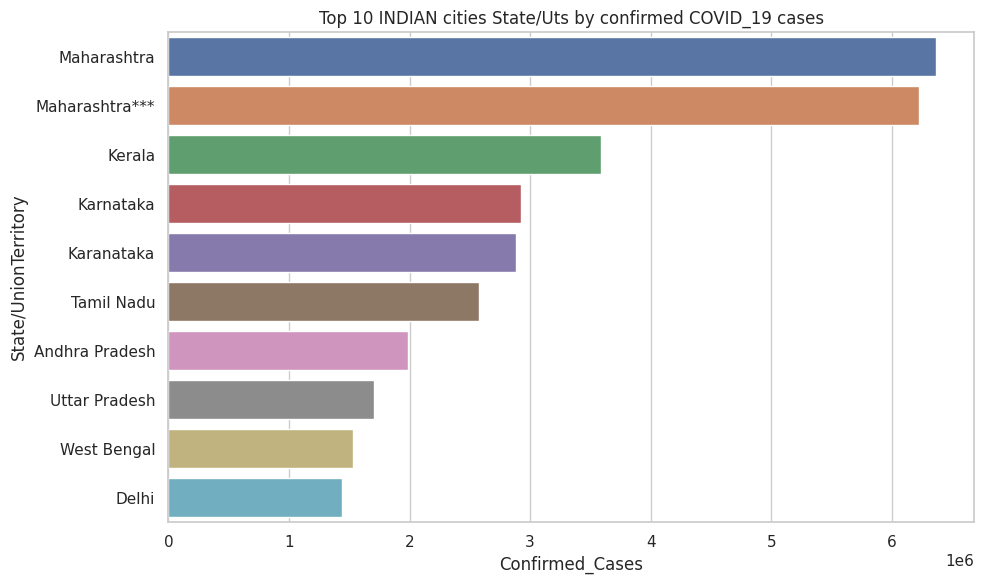

In [35]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.barplot(
    data= top10,
    y= "State/UnionTerritory",
    x = "Confirmed",
    # palette = ["Green","Pink","Cyan"],
    # palette="viridis",          # this is for hue
    hue = "State/UnionTerritory"
)
plt.title("Top 10 INDIAN cities State/Uts by confirmed COVID_19 cases")
plt.ylabel("State/UnionTerritory")
plt.xlabel("Confirmed_Cases")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1852/3190100636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1852/3190100636.py:4: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


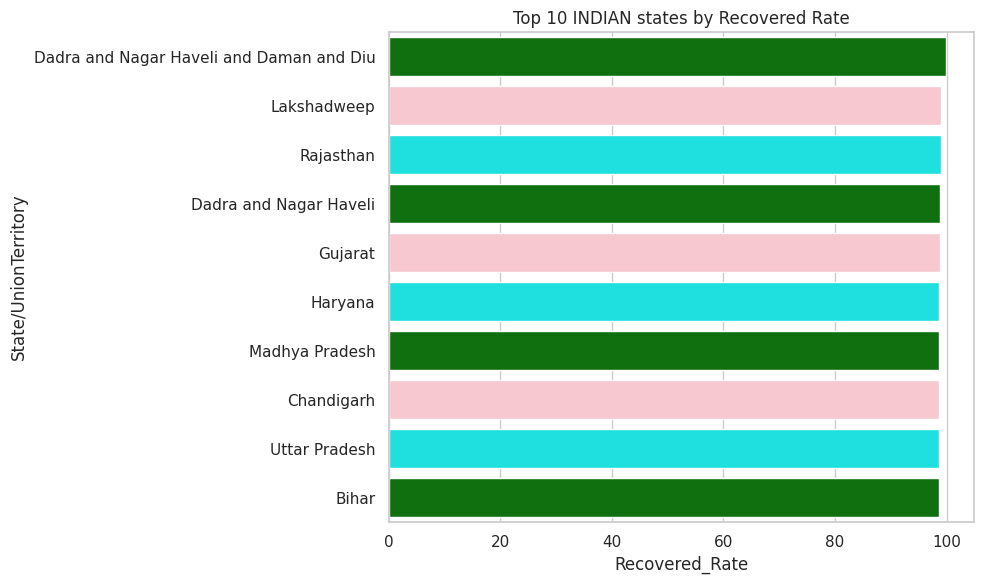

In [41]:
 # Recovery Rate vs Death Rate
rate_data = state_data.sort_values("Recovered_Rate", ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    data = rate_data,
    y = "State/UnionTerritory",
    x = "Recovered_Rate",
    palette = ["Green", "Pink", "Cyan"]
)
plt.title("Top 10 INDIAN states by Recovered Rate")
plt.ylabel("State/UnionTerritory")
plt.xlabel("Recovered_Rate")
plt.tight_layout()
plt.show()

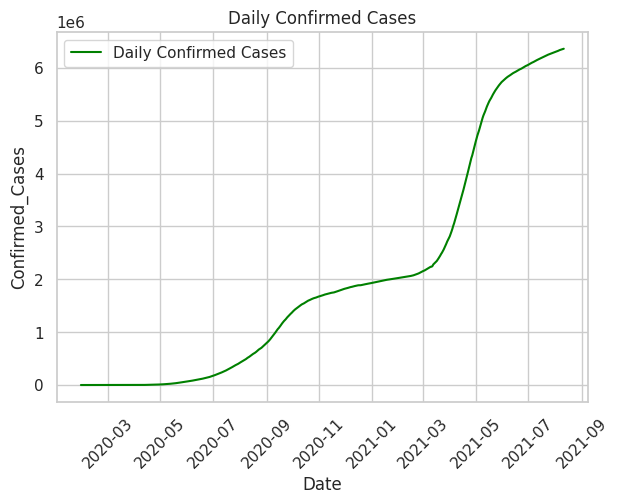

In [37]:
daily_cases = (
    df.groupby("Date")
    ["Confirmed"].max().reset_index()
)
sns.lineplot(
    data = daily_cases,
    x = "Date",
    y = "Confirmed",
    color = "green",
    label = "Daily Confirmed Cases"
)
plt.title("Daily Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed_Cases")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()